🔹 Dataset Shape: (30089, 25)

🔹 Missing Values:
 Unnamed: 0                    0
duration NUMERIC              0
total_fiat NUMERIC            0
total_biat NUMERIC            0
min_fiat NUMERIC              0
min_biat NUMERIC              0
max_fiat NUMERIC              0
max_biat NUMERIC              0
mean_fiat NUMERIC             0
mean_biat NUMERIC             0
flowPktsPerSecond NUMERIC     0
flowBytesPerSecond NUMERIC    0
min_flowiat NUMERIC           0
max_flowiat NUMERIC           0
mean_flowiat NUMERIC          0
std_flowiat NUMERIC           0
min_active NUMERIC            0
mean_active NUMERIC           0
max_active NUMERIC            0
std_active NUMERIC            0
min_idle NUMERIC              0
mean_idle NUMERIC             0
max_idle NUMERIC              0
std_idle NUMERIC              0
class1                        0
dtype: int64


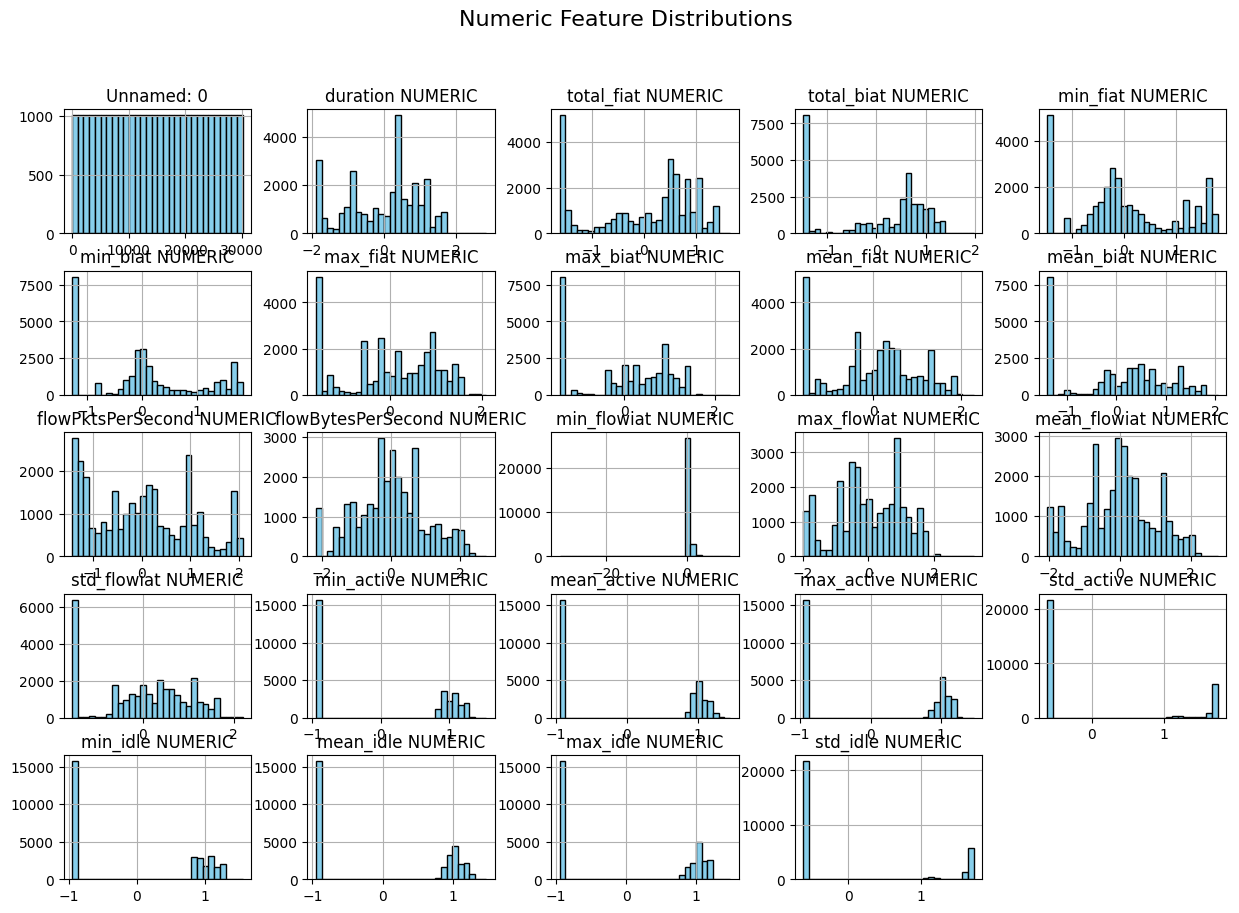

/tmp/ipython-input-3238737706.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="viridis")


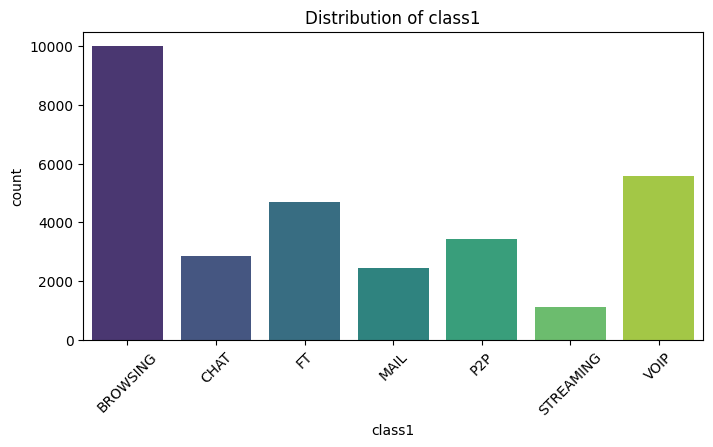

/tmp/ipython-input-3238737706.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette="coolwarm")


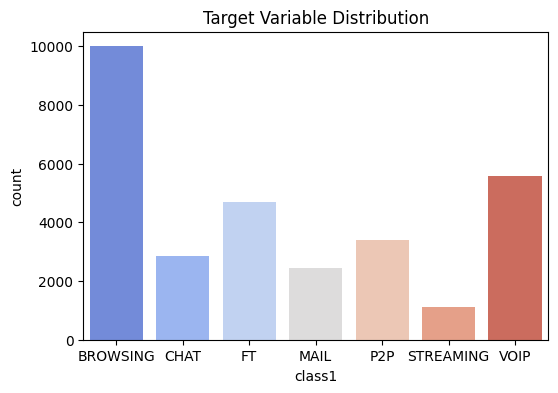


🔹 Summary Statistics (Numeric Columns):
                              count          mean          std        min  \
Unnamed: 0                  30089.0  1.504400e+04  8686.090461   0.000000   
duration NUMERIC            30089.0  1.341315e-16     1.000017  -1.879255   
total_fiat NUMERIC          30089.0 -7.556704e-18     1.000017  -1.631082   
total_biat NUMERIC          30089.0 -1.511341e-17     1.000017  -1.470835   
min_fiat NUMERIC            30089.0  2.644847e-17     1.000017  -1.484397   
min_biat NUMERIC            30089.0 -1.738042e-16     1.000017  -1.266187   
max_fiat NUMERIC            30089.0  1.171289e-16     1.000017  -1.611416   
max_biat NUMERIC            30089.0  2.644847e-17     1.000017  -1.431554   
mean_fiat NUMERIC           30089.0 -1.889176e-17     1.000017  -1.600358   
mean_biat NUMERIC           30089.0  2.267011e-16     1.000017  -1.401866   
flowPktsPerSecond NUMERIC   30089.0 -7.556704e-18     1.000017  -1.422009   
flowBytesPerSecond NUMERIC  30089.0

In [ ]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose your dataset is a DataFrame called df
df = pd.read_csv("/content/new_good_distributed_seneriyo_A_data.csv")

# 🔹 1️⃣ Basic Info
print("🔹 Dataset Shape:", df.shape)
print("\n🔹 Missing Values:\n", df.isnull().sum())

# 🔹 2️⃣ Numeric Feature Distribution
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.show()

# 🔹 3️⃣ Categorical Feature Distribution
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, palette="viridis")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

# 🔹 4️⃣ Target Variable Distribution
target_col = 'class1'  # replace with your actual target column name
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette="coolwarm")
plt.title("Target Variable Distribution")
plt.show()

# 🔹 5️⃣ Summary Statistics
print("\n🔹 Summary Statistics (Numeric Columns):")
print(df.describe().T)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: df = pd.read_csv("your_data.csv")

# 🔹 Detect numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 🔹 Check skewness
print("🔹 Skewness before log transformation:")
print(df[numeric_cols].skew().sort_values(ascending=False))


🔹 Skewness before log transformation:
flowBytesPerSecond NUMERIC    38.202862
flowPktsPerSecond NUMERIC     20.248287
min_flowiat NUMERIC           20.067956
std_idle NUMERIC              14.989706
std_active NUMERIC            13.985762
min_idle NUMERIC              13.586974
min_active NUMERIC            13.428371
mean_idle NUMERIC             12.618191
mean_active NUMERIC           12.428536
max_biat NUMERIC              11.736976
max_flowiat NUMERIC           10.948196
max_idle NUMERIC              10.876905
max_active NUMERIC            10.544917
min_fiat NUMERIC               4.892102
min_biat NUMERIC               4.869890
mean_fiat NUMERIC              4.253679
mean_flowiat NUMERIC           4.246172
mean_biat NUMERIC              4.018900
std_flowiat NUMERIC            3.876237
total_biat NUMERIC             3.806464
duration NUMERIC               3.648348
max_fiat NUMERIC               2.874092
total_fiat NUMERIC             2.029122
dtype: float64


In [ ]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

pt = PowerTransformer(method='yeo-johnson')
df_yeojohnson = pd.DataFrame(pt.fit_transform(df[numeric_cols]), columns=numeric_cols)

print("✅ Yeo-Johnson transform applied successfully.")



✅ Yeo-Johnson transform applied successfully.


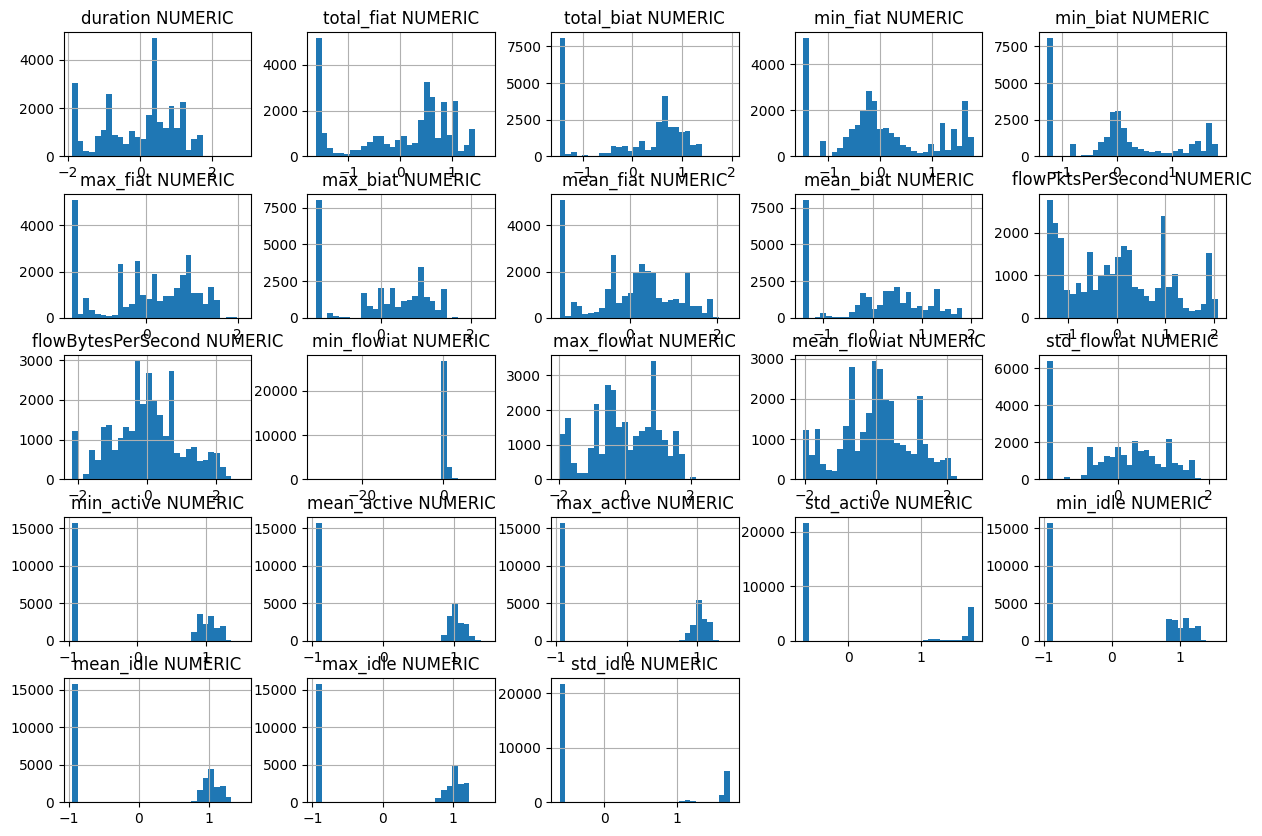

std_active NUMERIC            1.023670
std_idle NUMERIC              1.021599
flowPktsPerSecond NUMERIC     0.274336
min_biat NUMERIC              0.262398
min_fiat NUMERIC              0.179543
min_idle NUMERIC              0.123549
min_active NUMERIC            0.118155
mean_idle NUMERIC             0.112193
max_idle NUMERIC              0.111937
mean_active NUMERIC           0.108086
max_active NUMERIC            0.107955
flowBytesPerSecond NUMERIC    0.011803
mean_flowiat NUMERIC         -0.088038
mean_fiat NUMERIC            -0.192407
mean_biat NUMERIC            -0.204256
max_flowiat NUMERIC          -0.206032
std_flowiat NUMERIC          -0.269887
max_fiat NUMERIC             -0.342136
max_biat NUMERIC             -0.349637
duration NUMERIC             -0.404487
total_biat NUMERIC           -0.528461
total_fiat NUMERIC           -0.537105
min_flowiat NUMERIC          -8.933271
dtype: float64


In [ ]:
df_yeojohnson.hist(bins=30, figsize=(15,10))
plt.show()

print(df_yeojohnson.skew().sort_values(ascending=False))



In [ ]:
df_yeojohnson

,duration NUMERIC,total_fiat NUMERIC,total_biat NUMERIC,min_fiat NUMERIC,min_biat NUMERIC,max_fiat NUMERIC,max_biat NUMERIC,mean_fiat NUMERIC,mean_biat NUMERIC,flowPktsPerSecond NUMERIC,...,mean_flowiat NUMERIC,std_flowiat NUMERIC,min_active NUMERIC,mean_active NUMERIC,max_active NUMERIC,std_active NUMERIC,min_idle NUMERIC,mean_idle NUMERIC,max_idle NUMERIC,std_idle NUMERIC
0,1.604370,1.429831,1.309034,-0.474400,-0.084529,1.553205,1.443635,-0.243472,-0.126556,0.909680,...,-0.652736,0.503700,1.283630,1.231990,1.217355,1.665799,1.302160,1.246724,1.231283,1.627139
1,1.451216,1.315457,1.220659,-0.559035,-0.272190,1.441865,1.354968,-0.214456,-0.064365,0.829386,...,-0.588978,0.500285,1.254768,1.207517,1.193386,1.679046,1.273602,1.220159,1.202468,1.438299
2,1.304432,1.206248,1.135613,-0.696122,-0.125571,1.243361,1.196041,-0.133895,-0.085884,0.808194,...,-0.572425,0.368073,0.876669,1.038671,1.133538,1.702699,0.862494,1.032594,1.149462,1.706548
3,0.994183,0.971314,0.951622,-1.059562,-0.818742,0.691270,0.744813,-0.249796,-0.166940,0.955204,...,-0.689665,0.073541,0.886100,0.980181,1.035848,1.684678,0.880405,0.948459,0.979928,1.671422
4,-0.806840,-0.561998,-0.318093,-0.366025,-0.196908,-0.586192,-0.228572,-0.926850,-0.753883,1.669295,...,-1.399636,-0.721688,-0.950373,-0.951957,-0.951961,-0.616866,-0.949522,-0.951297,-0.951314,-0.617239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30084,1.082999,1.040141,1.002767,1.269471,1.378904,0.866022,0.890116,1.112254,1.152775,-1.159347,...,1.137984,1.006825,1.088062,1.047911,1.022686,1.521383,1.094364,1.059630,1.035128,1.635342
30085,-1.565843,-1.631082,-1.470835,-1.484397,-1.266187,-1.611416,-1.431554,-1.600358,-1.401866,1.579900,...,-1.170186,-1.544535,-0.950373,-0.951957,-0.951961,-0.616866,-0.949522,-0.951297,-0.951314,-0.617239
30086,0.506724,-1.631082,0.647648,-1.484397,1.700419,-1.611416,1.028560,-1.600358,1.418701,-1.279326,...,1.634377,1.354959,1.140990,1.097628,1.073942,-0.616866,1.160334,1.114646,1.090928,-0.617239
30087,1.083735,1.040699,0.893667,1.268873,1.378917,0.865774,0.890155,1.046562,1.140660,-1.159632,...,1.138566,0.957695,0.890924,0.999439,1.022683,1.686888,0.909870,1.011556,1.035082,1.689537


In [ ]:
new = pd.concat([df_yeojohnson, df['class1']], axis=1)

In [ ]:
new.to_csv("new_good_distributed_seneriyo_A_data.csv")

In [ ]:
new

,duration NUMERIC,total_fiat NUMERIC,total_biat NUMERIC,min_fiat NUMERIC,min_biat NUMERIC,max_fiat NUMERIC,max_biat NUMERIC,mean_fiat NUMERIC,mean_biat NUMERIC,flowPktsPerSecond NUMERIC,...,std_flowiat NUMERIC,min_active NUMERIC,mean_active NUMERIC,max_active NUMERIC,std_active NUMERIC,min_idle NUMERIC,mean_idle NUMERIC,max_idle NUMERIC,std_idle NUMERIC,class1
0,1.604370,1.429831,1.309034,-0.474400,-0.084529,1.553205,1.443635,-0.243472,-0.126556,0.909680,...,0.503700,1.283630,1.231990,1.217355,1.665799,1.302160,1.246724,1.231283,1.627139,BROWSING
1,1.451216,1.315457,1.220659,-0.559035,-0.272190,1.441865,1.354968,-0.214456,-0.064365,0.829386,...,0.500285,1.254768,1.207517,1.193386,1.679046,1.273602,1.220159,1.202468,1.438299,BROWSING
2,1.304432,1.206248,1.135613,-0.696122,-0.125571,1.243361,1.196041,-0.133895,-0.085884,0.808194,...,0.368073,0.876669,1.038671,1.133538,1.702699,0.862494,1.032594,1.149462,1.706548,BROWSING
3,0.994183,0.971314,0.951622,-1.059562,-0.818742,0.691270,0.744813,-0.249796,-0.166940,0.955204,...,0.073541,0.886100,0.980181,1.035848,1.684678,0.880405,0.948459,0.979928,1.671422,BROWSING
4,-0.806840,-0.561998,-0.318093,-0.366025,-0.196908,-0.586192,-0.228572,-0.926850,-0.753883,1.669295,...,-0.721688,-0.950373,-0.951957,-0.951961,-0.616866,-0.949522,-0.951297,-0.951314,-0.617239,BROWSING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30084,1.082999,1.040141,1.002767,1.269471,1.378904,0.866022,0.890116,1.112254,1.152775,-1.159347,...,1.006825,1.088062,1.047911,1.022686,1.521383,1.094364,1.059630,1.035128,1.635342,VOIP
30085,-1.565843,-1.631082,-1.470835,-1.484397,-1.266187,-1.611416,-1.431554,-1.600358,-1.401866,1.579900,...,-1.544535,-0.950373,-0.951957,-0.951961,-0.616866,-0.949522,-0.951297,-0.951314,-0.617239,VOIP
30086,0.506724,-1.631082,0.647648,-1.484397,1.700419,-1.611416,1.028560,-1.600358,1.418701,-1.279326,...,1.354959,1.140990,1.097628,1.073942,-0.616866,1.160334,1.114646,1.090928,-0.617239,VOIP
30087,1.083735,1.040699,0.893667,1.268873,1.378917,0.865774,0.890155,1.046562,1.140660,-1.159632,...,0.957695,0.890924,0.999439,1.022683,1.686888,0.909870,1.011556,1.035082,1.689537,VOIP


In [ ]:
x = pd.read_csv("/content/senerio_A_B_merged_vpn.csv")

🔹 Dataset Shape: (30089, 24)

🔹 Missing Values:
 duration NUMERIC              0
total_fiat NUMERIC            0
total_biat NUMERIC            0
min_fiat NUMERIC              0
min_biat NUMERIC              0
max_fiat NUMERIC              0
max_biat NUMERIC              0
mean_fiat NUMERIC             0
mean_biat NUMERIC             0
flowPktsPerSecond NUMERIC     0
flowBytesPerSecond NUMERIC    0
min_flowiat NUMERIC           0
max_flowiat NUMERIC           0
mean_flowiat NUMERIC          0
std_flowiat NUMERIC           0
min_active NUMERIC            0
mean_active NUMERIC           0
max_active NUMERIC            0
std_active NUMERIC            0
min_idle NUMERIC              0
mean_idle NUMERIC             0
max_idle NUMERIC              0
std_idle NUMERIC              0
class1                        0
dtype: int64


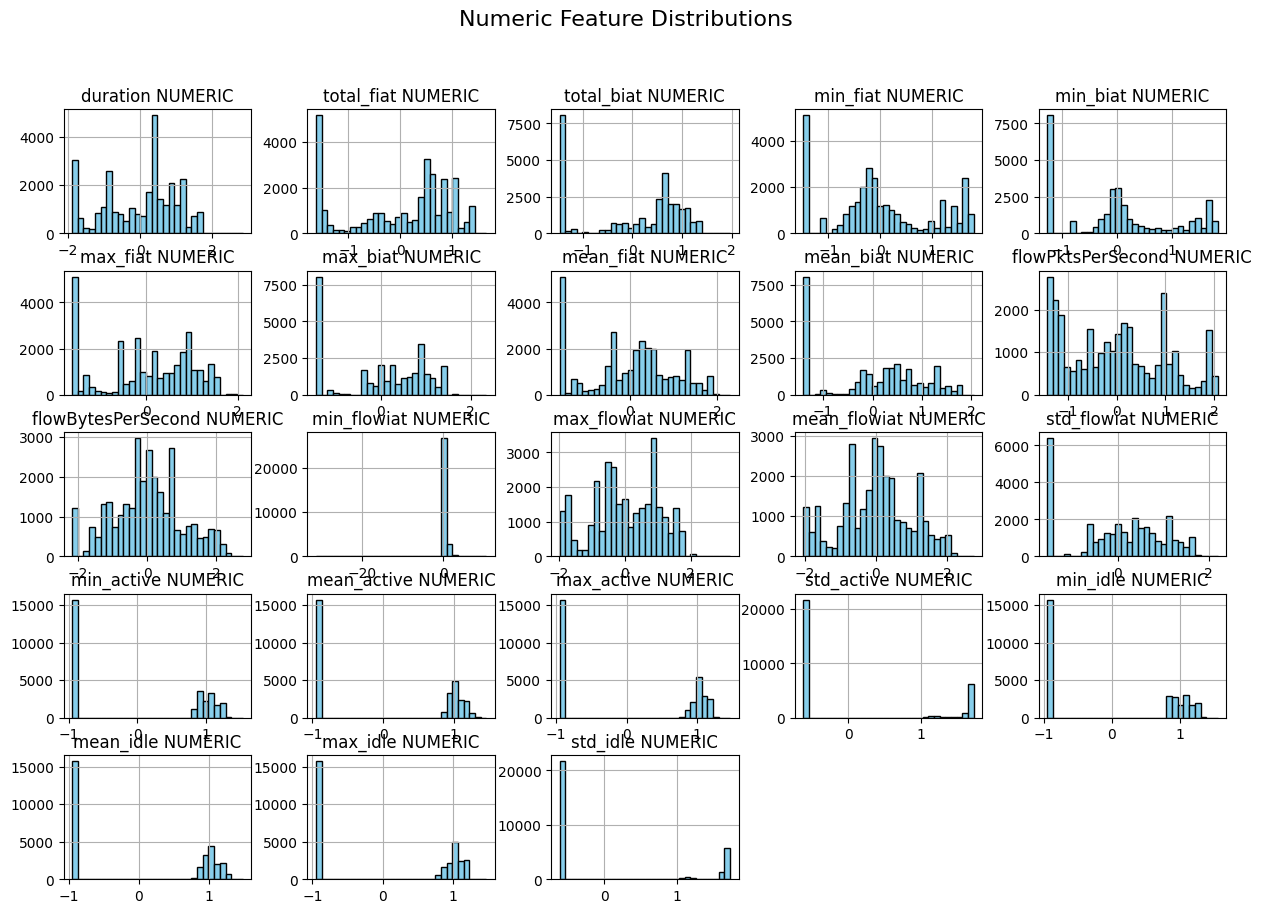

/tmp/ipython-input-2023621913.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="viridis")


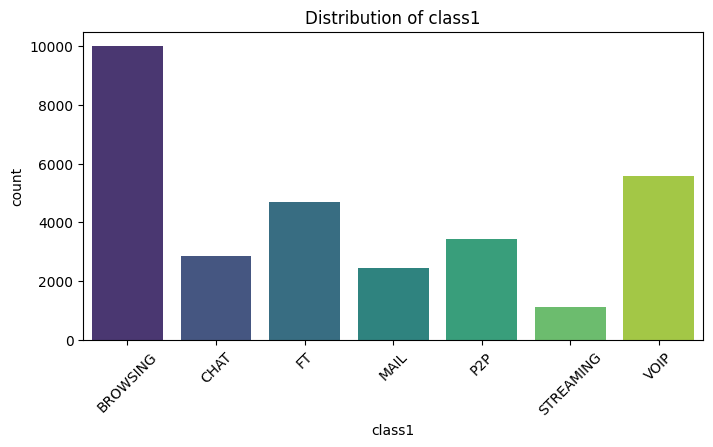

/tmp/ipython-input-2023621913.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette="coolwarm")


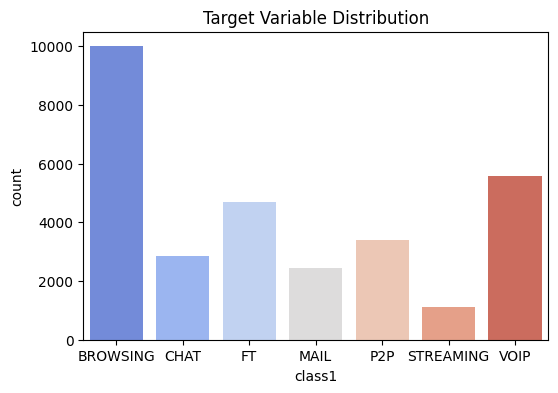


🔹 Summary Statistics (Numeric Columns):
                              count          mean       std        min  \
duration NUMERIC            30089.0  1.341315e-16  1.000017  -1.879255   
total_fiat NUMERIC          30089.0  7.178869e-17  1.000017  -1.631082   
total_biat NUMERIC          30089.0 -1.511341e-17  1.000017  -1.470835   
min_fiat NUMERIC            30089.0  3.022682e-17  1.000017  -1.484397   
min_biat NUMERIC            30089.0 -1.549124e-16  1.000017  -1.266187   
max_fiat NUMERIC            30089.0  1.133506e-16  1.000017  -1.611416   
max_biat NUMERIC            30089.0  3.400517e-17  1.000017  -1.431554   
mean_fiat NUMERIC           30089.0 -7.556704e-18  1.000017  -1.600358   
mean_biat NUMERIC           30089.0  1.964743e-16  1.000017  -1.401866   
flowPktsPerSecond NUMERIC   30089.0 -7.556704e-18  1.000017  -1.422009   
flowBytesPerSecond NUMERIC  30089.0  7.556704e-17  1.000017  -2.163019   
min_flowiat NUMERIC         30089.0 -1.511341e-17  1.000017 -31.540834 

In [ ]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose your dataset is a DataFrame called df
df = new

# 🔹 1️⃣ Basic Info
print("🔹 Dataset Shape:", df.shape)
print("\n🔹 Missing Values:\n", df.isnull().sum())

# 🔹 2️⃣ Numeric Feature Distribution
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.show()

# 🔹 3️⃣ Categorical Feature Distribution
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, palette="viridis")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

# 🔹 4️⃣ Target Variable Distribution
target_col = 'class1'  # replace with your actual target column name
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette="coolwarm")
plt.title("Target Variable Distribution")
plt.show()

# 🔹 5️⃣ Summary Statistics
print("\n🔹 Summary Statistics (Numeric Columns):")
print(df.describe().T)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

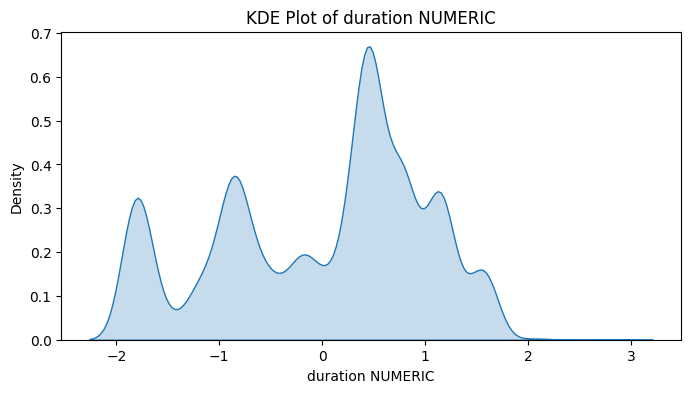

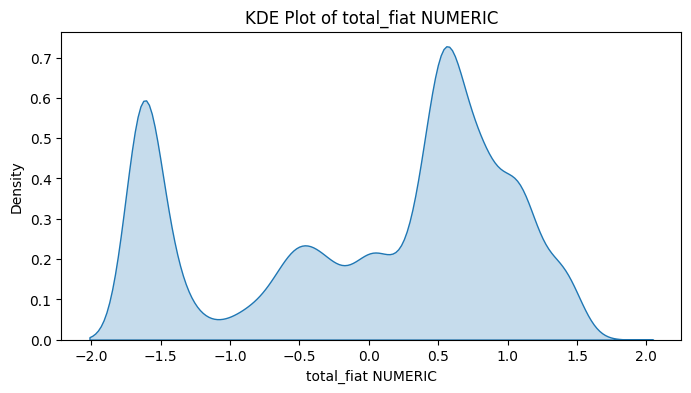

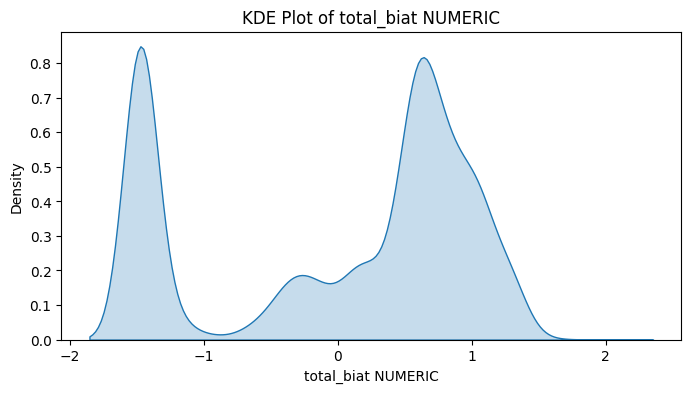

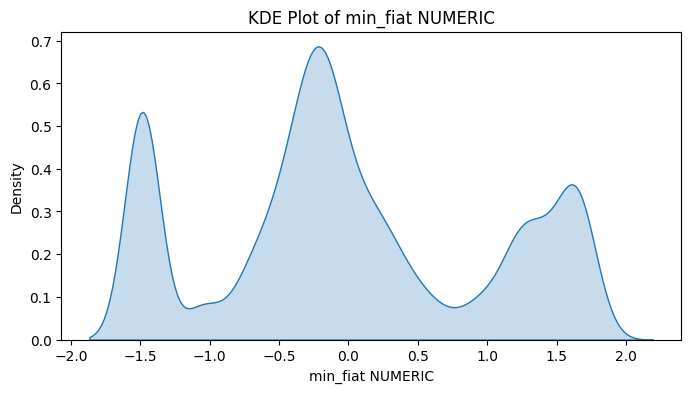

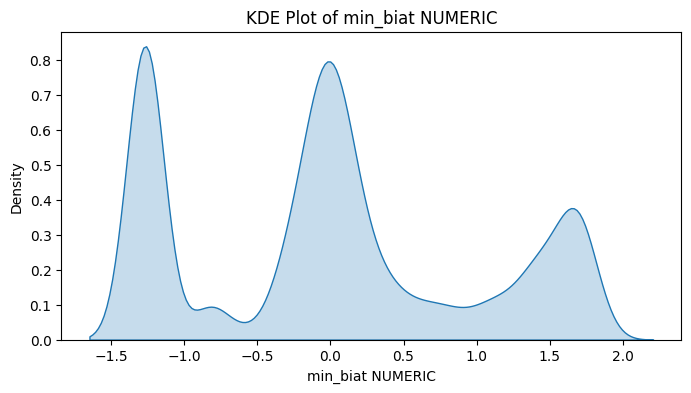

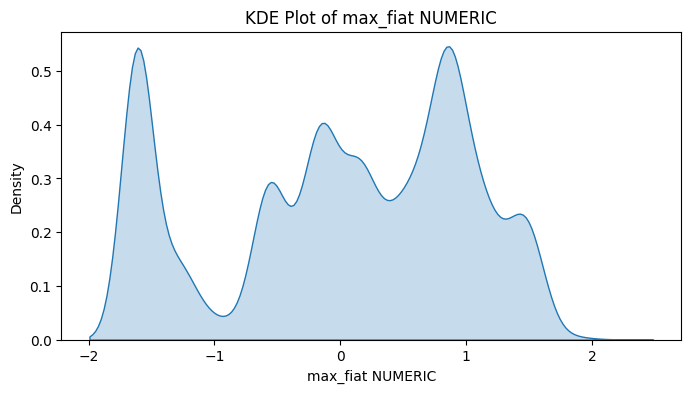

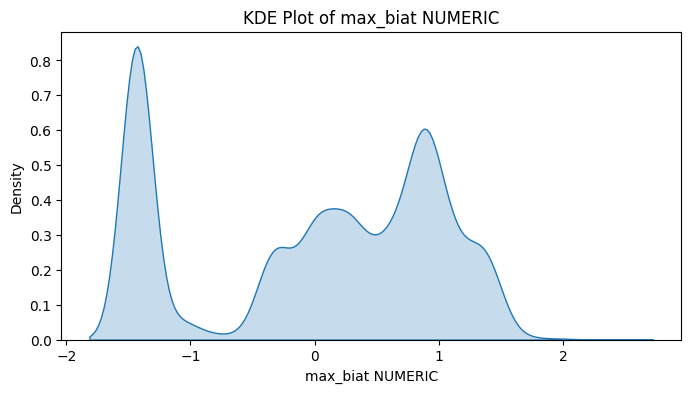

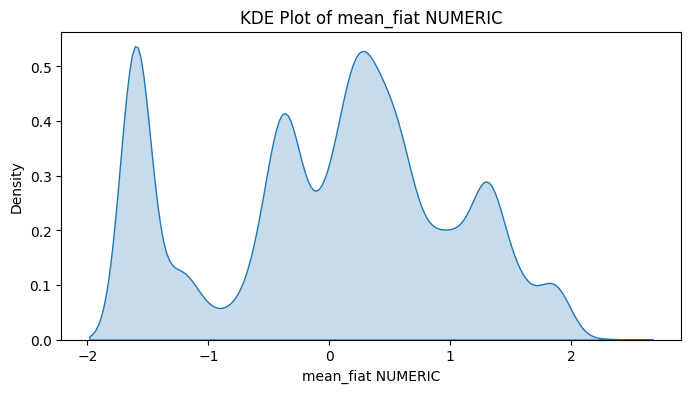

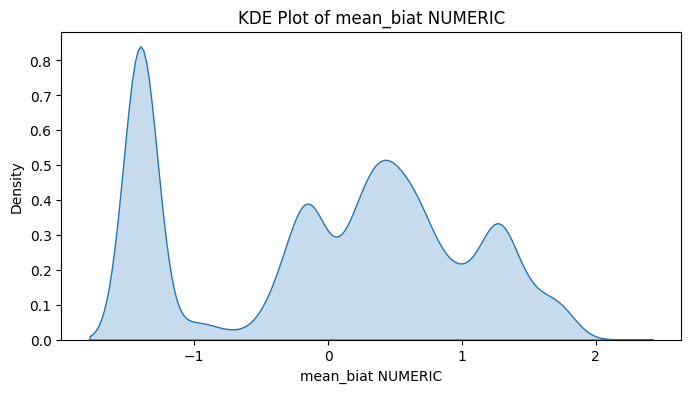

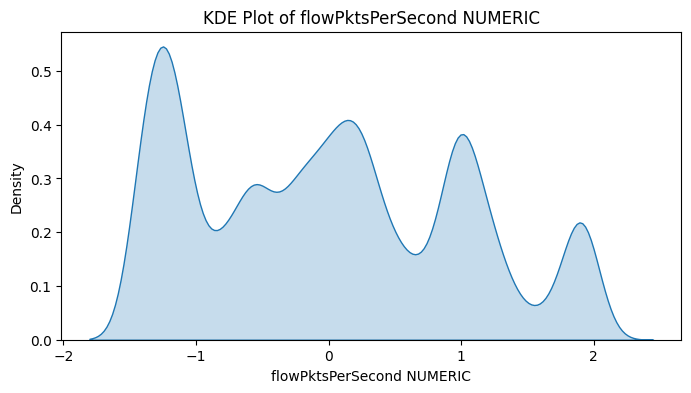

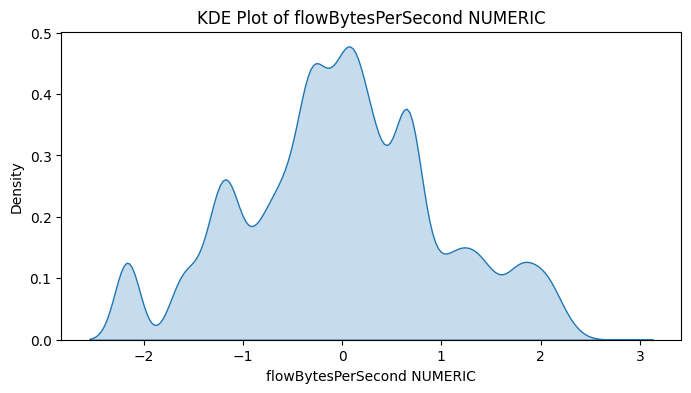

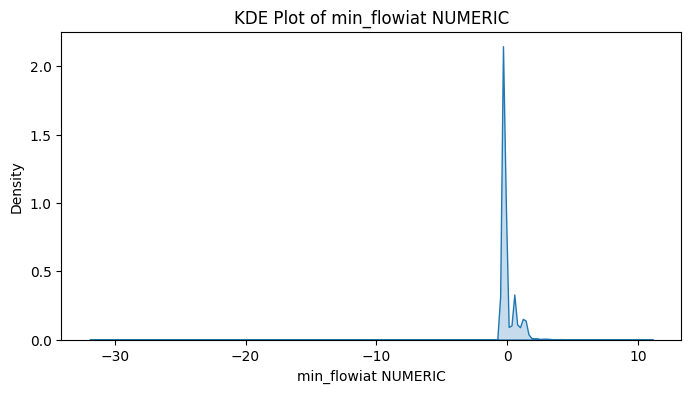

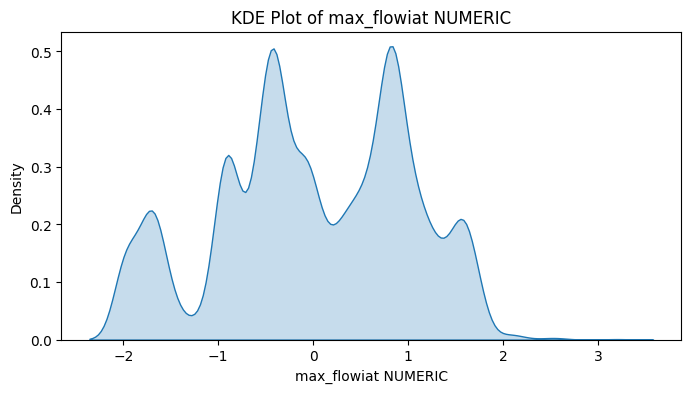

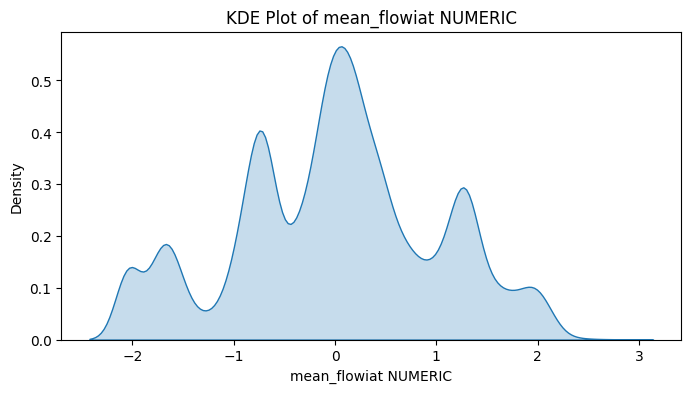

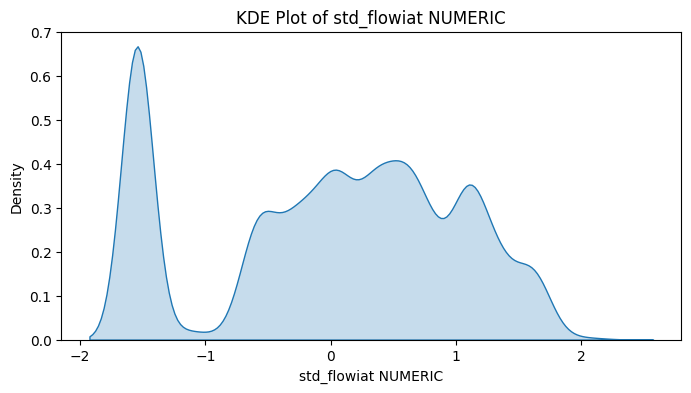

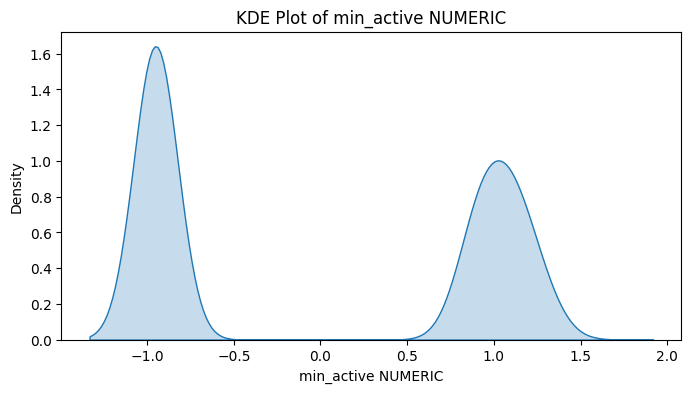

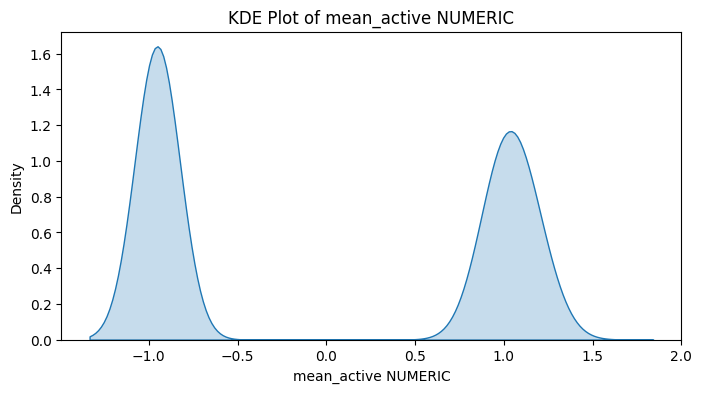

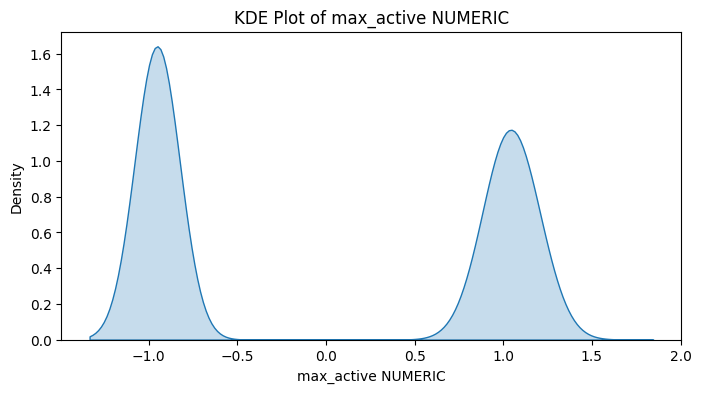

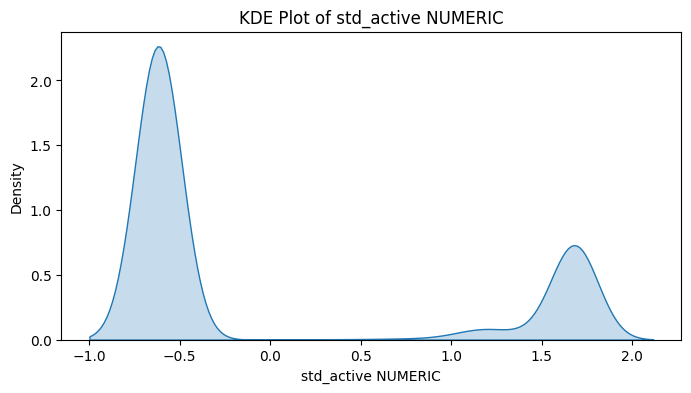

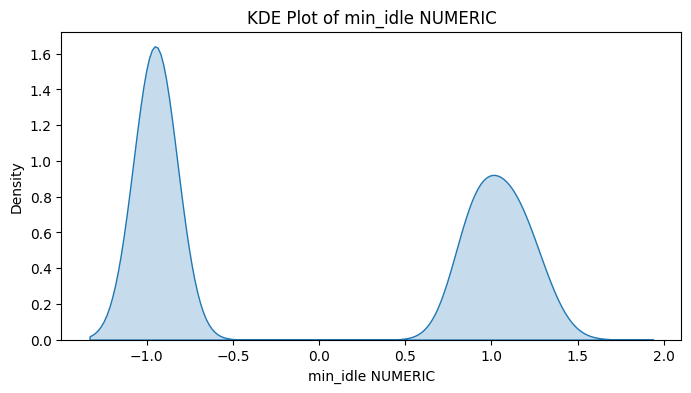

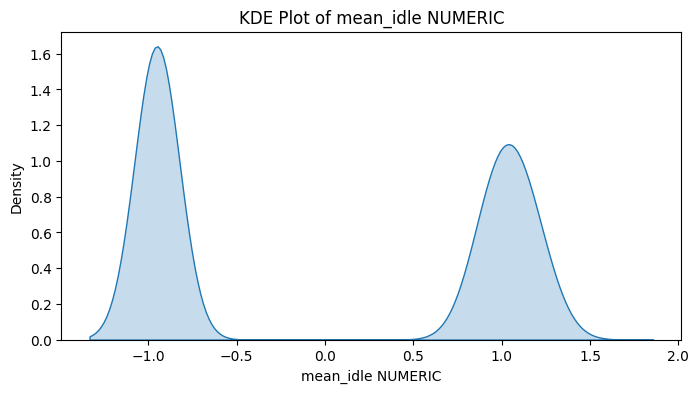

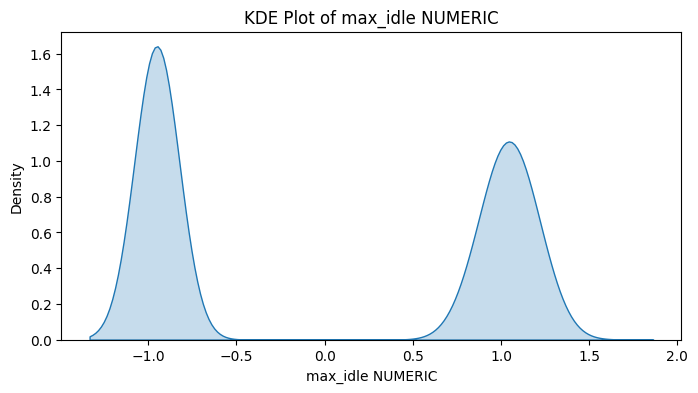

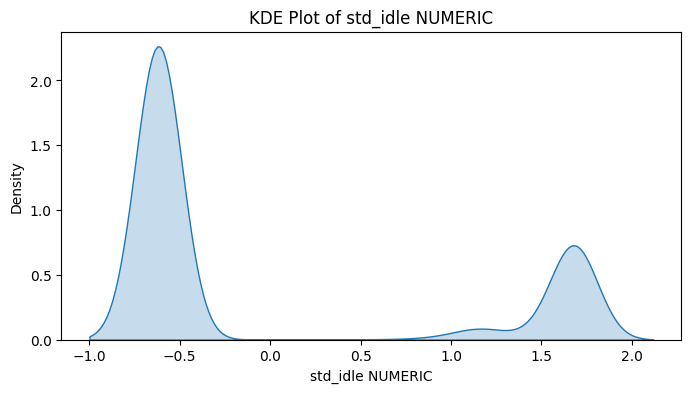

In [ ]:
# Assuming 'new' is your DataFrame with the transformed data
numeric_cols = new.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=new, x=col, fill=True)
    plt.title(f'KDE Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()